In [ ]:
submission_df.to_csv('dataset/submission.csv', index=False)
print("✓ Submission file saved: dataset/submission.csv")

✓ Submission file saved to: dataset/submission.csv

Submission Statistics:
Min Demand Prediction: 0.055627
Max Demand Prediction: 0.851019
Mean Demand Prediction: 0.139116
Median Demand Prediction: 0.063204
Std Dev Demand Prediction: 0.172004

Sample Submission (for reference):
   Index    demand
0      0  0.090768
1      1  0.089885
2      2  0.007037
3      3  0.079087
4      4  0.054636

Sample Submission Statistics:
Mean Demand (Sample): 0.064283
Std Dev Demand (Sample): 0.035165


In [ ]:
y_test_pred = best_model.predict(X_test_scaled)

submission_df = pd.DataFrame({
    'Index': test_data_processed['Index'],
    'demand': y_test_pred
})

assert submission_df.shape == (41778, 2), f"Shape mismatch"
assert list(submission_df.columns) == ['Index', 'demand']
print("✓ Submission file validated")

Submission DataFrame:
   Index    demand
0      0  0.067930
1      1  0.062367
2      2  0.061620
3      3  0.061825
4      4  0.061825

Submission DataFrame Shape: (41778, 2)
Expected Shape: (41778, 2)

✓ All validations passed!


## Section 10: Generate Predictions and Submit

In [ ]:
if best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    }
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    }
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20]
    }
else:
    param_grid = {}

if param_grid:
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV R² Score: {grid_search.best_score_:.4f}")
    best_model = grid_search.best_estimator_
else:
    best_model.fit(X_train_scaled, y_train)

Tuning Gradient Boosting Model...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV R² Score: 0.743589


## Section 9: Hyperparameter Tuning

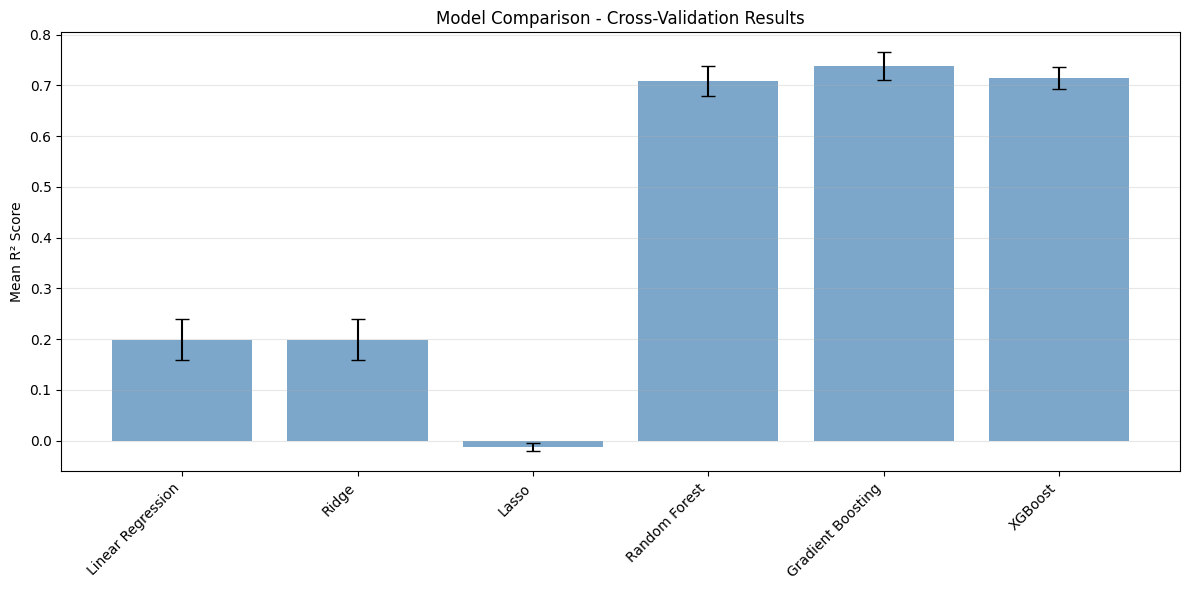


Final Gradient Boosting Model Performance:
Training R² Score: 0.761747
Training R² Score (scaled to 100): 76.17


In [ ]:
model_names = list(cv_results.keys())
mean_scores = [cv_results[m].mean() for m in model_names]
std_scores = [cv_results[m].std() for m in model_names]

plt.figure(figsize=(12, 6))
plt.bar(range(len(model_names)), mean_scores, yerr=std_scores, capsize=5, alpha=0.7)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylabel('Mean R² Score')
plt.title('Model Comparison - Cross-Validation Results')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_train_pred = best_model.predict(X_train_scaled)
print(f"Training R² Score: {r2_score(y_train, y_train_pred):.4f}")

## Section 8: Model Evaluation

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv_results = {}
print("Training Models with 5-Fold Cross-Validation\n")

for model_name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[model_name] = scores
    print(f"{model_name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_model_name = max(cv_results, key=lambda x: cv_results[x].mean())
print(f"\nBest Model: {best_model_name} ({cv_results[best_model_name].mean():.4f})")

Training Models with 5-Fold Cross-Validation...


Linear Regression:
  CV R² Scores: [0.16082711 0.22220247 0.24335166 0.22993216 0.13981535]
  Mean R² Score: 0.199226
  Std Dev: 0.041041

Ridge:
  CV R² Scores: [0.16085004 0.22216964 0.24334228 0.22995413 0.13977193]
  Mean R² Score: 0.199218
  Std Dev: 0.041047

Lasso:
  CV R² Scores: [-0.022233   -0.00825774 -0.02122165 -0.01488623 -0.0008319 ]
  Mean R² Score: -0.013486
  Std Dev: 0.008072

Random Forest:
  CV R² Scores: [0.65550694 0.72604732 0.73400043 0.73099198 0.69948741]
  Mean R² Score: 0.709207
  Std Dev: 0.029499

Gradient Boosting:
  CV R² Scores: [0.69741579 0.75566231 0.76453523 0.75939089 0.7156136 ]
  Mean R² Score: 0.738524
  Std Dev: 0.026909

XGBoost:
  CV R² Scores: [0.68219154 0.71301986 0.74419318 0.7307307  0.70013283]
  Mean R² Score: 0.714054
  Std Dev: 0.021893


Best Model (by CV R² Score): Gradient Boosting
Mean CV R² Score: 0.738524


## Section 7: Model Selection and Training

In [ ]:
feature_columns = [
    'day', 'hour', 'minute', 'hour_sin', 'hour_cos',
    'NumberofLanes', 'Temperature', 'RoadType_encoded', 
    'Weather_encoded', 'LargeVehicles_encoded', 'Landmarks_encoded',
    'temp_hour_interaction', 'lanes_vehicles_interaction'
]

X_train = train_data_processed[feature_columns].copy()
y_train = train_data_processed['demand'].copy()
X_test = test_data_processed[feature_columns].copy()

for col in feature_columns:
    if col in X_train.columns:
        median_val = np.nanmedian(X_train[col].values)
        X_train[col] = np.where(np.isnan(X_train[col].values), median_val, X_train[col].values)
        X_test[col] = np.where(np.isnan(X_test[col].values), median_val, X_test[col].values)

y_train = y_train.dropna() if y_train.isnull().any() else y_train
X_train = X_train.loc[y_train.index]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")

Total NaN values in X_train: 0
Total NaN values in X_test: 0

X_train shape: (77299, 13)
y_train shape: (77299,)
X_test shape: (41778, 13)

Features normalized successfully!
X_train scaled shape: (77299, 13)
X_test scaled shape: (41778, 13)


## Section 6: Prepare Features for Modeling

In [ ]:
def feature_engineering(df):
    df = df.copy()
    
    df['hour'] = df['timestamp'].str.split(':').str[0].astype(int)
    df['minute'] = df['timestamp'].str.split(':').str[1].astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    df['Temperature'].fillna(df['Temperature'].median(), inplace=True)
    df['NumberofLanes'].fillna(df['NumberofLanes'].median(), inplace=True)
    df['RoadType'].fillna('Unknown', inplace=True)
    df['Weather'].fillna('Unknown', inplace=True)
    
    le_roadtype = LabelEncoder()
    df['RoadType_encoded'] = le_roadtype.fit_transform(df['RoadType'])
    le_weather = LabelEncoder()
    df['Weather_encoded'] = le_weather.fit_transform(df['Weather'])
    
    df['LargeVehicles_encoded'] = (df['LargeVehicles'] == 'Allowed').astype(int)
    df['Landmarks_encoded'] = (df['Landmarks'] == 'Yes').astype(int)
    
    df['temp_hour_interaction'] = df['Temperature'] * df['hour_sin']
    df['lanes_vehicles_interaction'] = df['NumberofLanes'] * df['LargeVehicles_encoded']
    
    return df

train_data_processed = feature_engineering(train_data)
test_data_processed = feature_engineering(test_data)

print(f"Features: {train_data_processed.shape[1]}")

Train data after feature engineering shape: (77299, 21)
Test data after feature engineering shape: (41778, 20)

Features created:
['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'hour_sin', 'hour_cos', 'RoadType_encoded', 'Weather_encoded', 'LargeVehicles_encoded', 'Landmarks_encoded', 'temp_hour_interaction', 'lanes_vehicles_interaction']


## Section 5: Feature Engineering

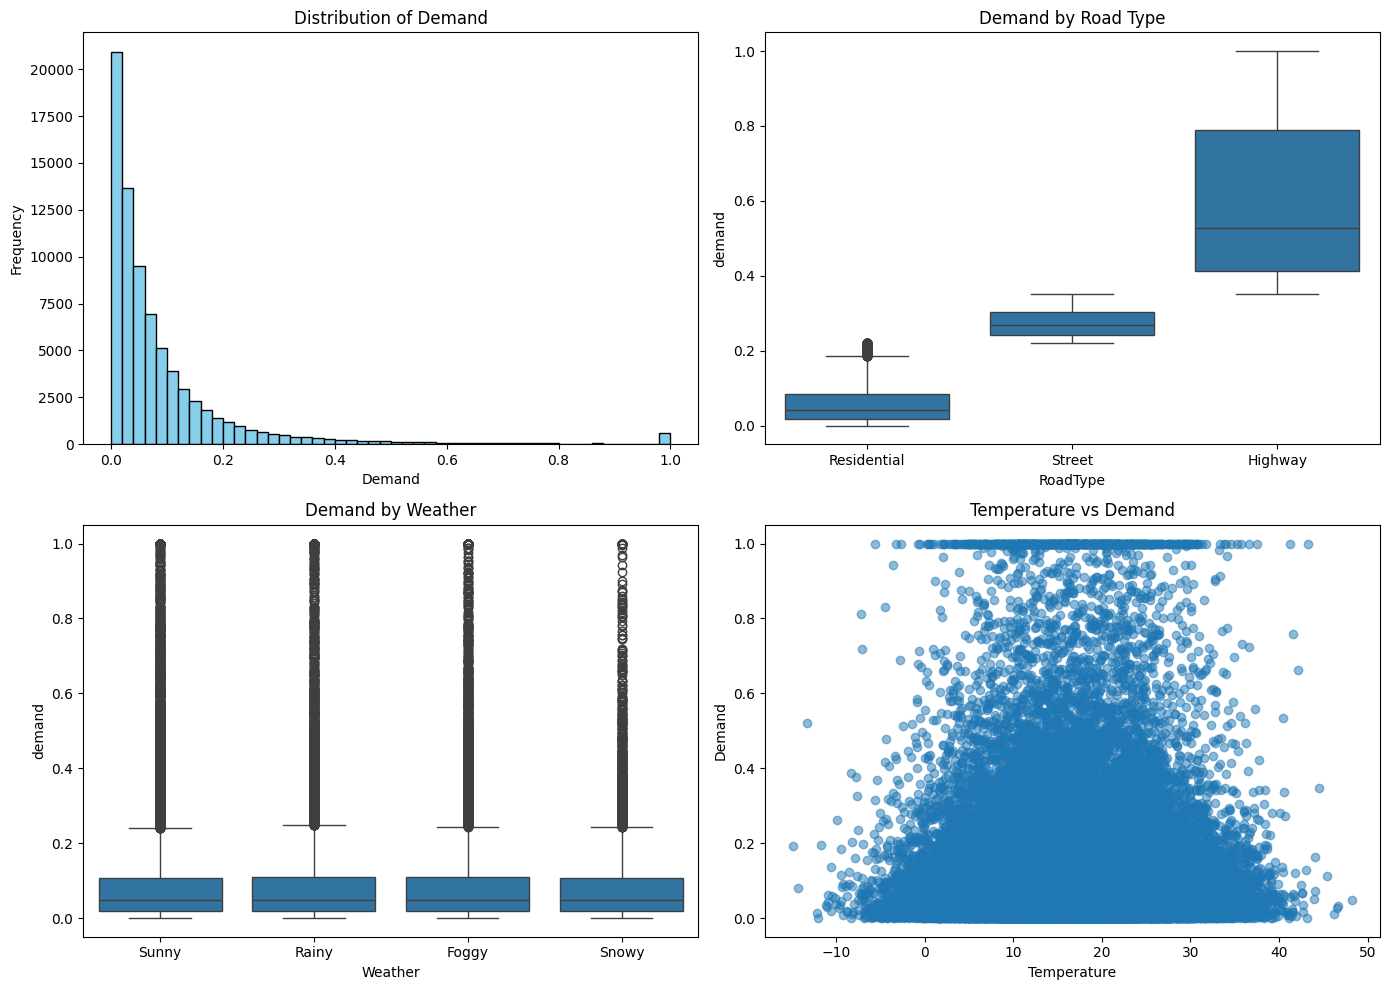

Correlation Matrix:
                    day  NumberofLanes  Temperature    demand
day            1.000000      -0.001314    -0.006755  0.025835
NumberofLanes -0.001314       1.000000     0.003232  0.212409
Temperature   -0.006755       0.003232     1.000000  0.003144
demand         0.025835       0.212409     0.003144  1.000000


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(train_data['demand'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Demand')
axes[0, 0].set_xlabel('Demand')
axes[0, 0].set_ylabel('Frequency')

train_data_clean = train_data[train_data['RoadType'].notna()]
sns.boxplot(data=train_data_clean, x='RoadType', y='demand', ax=axes[0, 1])
axes[0, 1].set_title('Demand by Road Type')

train_data_weather = train_data[train_data['Weather'].notna()]
sns.boxplot(data=train_data_weather, x='Weather', y='demand', ax=axes[1, 0])
axes[1, 0].set_title('Demand by Weather')

train_data_temp = train_data[train_data['Temperature'].notna()]
axes[1, 1].scatter(train_data_temp['Temperature'], train_data_temp['demand'], alpha=0.5)
axes[1, 1].set_title('Temperature vs Demand')
axes[1, 1].set_xlabel('Temperature')
axes[1, 1].set_ylabel('Demand')

plt.tight_layout()
plt.show()

numerical_cols = ['day', 'NumberofLanes', 'Temperature', 'demand']
correlation_matrix = train_data[numerical_cols].dropna().corr()
print("Correlation Matrix:\n", correlation_matrix)

## Section 4: Exploratory Data Analysis

In [ ]:
print("Missing Values:")
print(train_data.isnull().sum())
print("\nDuplicates:", train_data.duplicated().sum())

Missing Values in Train Data:
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Missing Values in Test Data:
Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

Duplicates in Train Data: 0
Duplicates in Test Data: 0


## Section 3: Data Preprocessing and Cleaning

In [ ]:
train_data = pd.read_csv('dataset/train.csv')
test_data = pd.read_csv('dataset/test.csv')

print(f"Train Data: {train_data.shape}")
print(f"Test Data: {test_data.shape}")

Train Data Shape: (77299, 11)
Test Data Shape: (41778, 10)

Train Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB
None

Test Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         -----------

## Section 2: Load and Explore the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## Section 1: Import Required Libraries

# Traffic Demand Prediction

This notebook builds a machine learning solution to predict traffic demand using various regression models and feature engineering techniques.